In [1]:
from cProfile import label
import os

import numpy as np
from scipy.stats import norm, lognorm
from scipy.integrate import trapezoid
from astropy.table import Table
from matplotlib import pyplot as plt
from iminuit import Minuit
from scipy.optimize._numdiff import approx_derivative
from scipy.interpolate import UnivariateSpline
from scipy.stats import norm, gamma
from scipy.stats import kstest
import argparse
from scipy.stats import levy_stable
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u



from astropy.time import Time, TimeDelta
from astropy.table import Table

# funictions

In [2]:
def plot_lightcurve(title, t, phi, ephi):
    fig, ax = plt.subplots(figsize=(10, 6), nrows=1, ncols = 1)
    plt.subplots_adjust(bottom = 0.1, top = 0.95, left=0.1, right=0.96, hspace=0.05)
    ax.set_title(title)
    ax.set_xlabel(r"Time [h]", ha="center", va = 'center', labelpad=12, fontsize=12)
    ax.set_ylabel(r"Energy flux [TeV cm$^{-2}$ s$^{-1}$]", ha="center", va = 'center', labelpad=12, fontsize=12)
    ax.set_yscale('log')
    ax.errorbar(t, phi, yerr = ephi, fmt='o',  mfc='none', color='k')
    #plt.savefig(f"{path}/Lightcurve.pdf", dpi=150)


In [3]:
def hist_flux(phi, ephi, rebin):
    #load the histogram
    phi_min, phi_max = np.min(phi-ephi), np.max(phi+ephi)
    phi_min = max(phi_min, 0.)
    bin_size_log10 = np.median( ephi/(phi*np.log(10)) )*rebin
    phi_min = np.min(phi[phi > 0])
    log10_phi_min, log10_phi_max = np.log10(phi_min), np.log10(phi_max) 
    bins = np.arange(log10_phi_min, log10_phi_max+bin_size_log10, bin_size_log10)
    hist, bin_edges = np.histogram(np.log10(phi), bins=bins)

    return hist, bin_edges

def plot_histo(title, phi, ephi, pdf, rebin=4):
    hist, bins = hist_flux(phi, ephi, rebin)

    #plot
    fig, ax = plt.subplots(figsize=(8, 6), nrows=1, ncols = 1)
    plt.subplots_adjust(bottom = 0.1, top = 0.95, left=0.1, right=0.96, hspace=0.05)
    ax.set_title(title)
    ax.set_xlabel(r"log$_{10}$(energy flux [TeV cm$^{-2}$ s$^{-1}$])", ha="center", va = 'center', labelpad=12, fontsize=12)
    ax.set_ylabel(r"# entries", ha="center", va = 'center', labelpad=12, fontsize=12)
    #ax.set_yscale('log')
    log_phi = np.log10(phi)
    ax.stairs(hist,bins)
    bin_centers = 0.5*(bins[1:]+bins[:-1])
    sel = hist>=1
    ax.errorbar(bin_centers[sel], hist[sel], yerr = np.sqrt(hist[sel]), fmt='',  mfc='none', color='tab:blue', ls='none')

    bin_size_log10 = bins[1]-bins[0]
    log10phi_plot = np.linspace(np.min(log_phi), np.max(log_phi))
    phi_plot = np.power(10, log10phi_plot)
    normalization_pdf = phi.size*bin_size_log10*np.log(10)
    ax.plot(log10phi_plot, phi_plot*pdf(phi_plot)*normalization_pdf)
    plt.show()

def pdf_Gauss(x, mu, sigma):
    return norm(loc=mu, scale=sigma).pdf(x)

def pdf_LogNorm(x, mu, sigma):
    rv = lognorm(s=sigma, scale=np.exp(mu))
    return rv.pdf(x)

def pdf_gammaf(x, a, b):
    return gamma.pdf(x, a, scale=1/b)


def pdf_alpha_stable(x, loc, scale, alpha, beta=1.0):
    return levy_stable.pdf(x, alpha, beta, loc=loc, scale=scale)

MODELS = {
    "lognorm": {
        "pdf": lambda x, m, s: pdf_LogNorm(x, m, s),
        "names": ["mu", "sigma"]
    },
    "gaussian": {
        "pdf": lambda x, m, s: pdf_Gauss(x, m, s),
        "names": ["mean", "std"]
    },
    "alpha": {
    "pdf": lambda x, alpha, loc, scale: pdf_alpha_stable(x, loc, scale, alpha),
    "names": ["alpha", "loc", "scale"]
}

}

def deviance(phi_i, ephi_i, pdf):

    #define the range of the integrand
    nsigma = 5

    #define the function to be integrated
    def integ(pdf_test, phi_0, ephi_0):
        #range for integration over the data uncertainties
        phi_int_min = np.min(phi_0 - nsigma*ephi_0)
        phi_int_max = np.max(phi_0 + nsigma*ephi_0)
        phi_integrand = np.linspace(phi_int_min, phi_int_max, 100)

        #integrand
        rv = norm(loc=phi_0,scale=ephi_0)
        integrand = rv.pdf(phi_integrand) * pdf_test(phi_integrand)
        return trapezoid(integrand, x=phi_integrand)

    #evaluate the integrand and its integral
    likelihood = np.array([integ(pdf, phi_i[i], ephi_i[i]) for i in range(phi_i.size)])
    lnL = np.sum(np.log(likelihood))

    #Saturated model - not sure it is the best one
    pdf_sat = lambda x: np.ones_like(x)
    likelihood_sat = np.array([integ(pdf_sat, phi_i[i], ephi_i[i]) for i in range(phi_i.size)])
    lnL_sat = np.sum(np.log(likelihood_sat))

    return -2*(lnL-lnL_sat)

def propagate_scipy_compatible(model, params, cov):
    """
    Computes output covariance via numerical Jacobian propagation.
    """
    params = np.asarray(params)
    cov = np.asarray(cov)

    y = model(params)
    J = approx_derivative(model, params, method="2-point")

    # Covariance propagation
    ycov = J @ cov @ J.T

    return y, ycov



def fitting(phi_i, ephi_i, init_mean, init_std, model="lognorm"):
    """
        Fits selected model on the data, giving best fit parameters and corresponding errors.
        Can be improved as the Gaussian fit is slow.
    """
    nsigma = 5
    if model not in MODELS:
        raise ValueError(f"Model '{model}' not supported. Choose from: {list(MODELS.keys())}")

    pdf_model = MODELS[model]["pdf"]
    param_names = MODELS[model]["names"]

    if model == "gaussian":
        def minimize_func(init_mean, init_std):
            var = init_std ** 2 + ephi_i ** 2
            logL_i = -0.5 * (np.log(2 * np.pi * var) + (phi_i - init_mean) ** 2 / var)

            return -np.sum(logL_i)

    elif model == "alpha":
        def minimize_func(alpha, loc, scale):
            logpdf_vals = levy_stable.logpdf(phi_i, alpha, 1.0, loc=loc, scale=scale)
            logpdf_vals = np.clip(logpdf_vals, -1e300, None)
            return -np.sum(logpdf_vals)

    else:
        def minimize_func(init_mean, init_std):
            # define the function to be integrated
            def integ(pdf_test, phi_0, ephi_0):
                # range for integration over the data uncertainties
                phi_int_min = np.min(phi_0 - nsigma * ephi_0)
                phi_int_max = np.max(phi_0 + nsigma * ephi_0)
                phi_integrand = np.linspace(phi_int_min, phi_int_max, 500)

                # integrand
                rv = norm(loc=phi_0, scale=ephi_0)
                integrand = rv.pdf(phi_integrand) *  pdf_test(phi_integrand, init_mean, init_std)
                integral_val = trapezoid(integrand, x=phi_integrand)
                integral_val = max(integral_val, 1e-300)
                return integral_val


            likelihood = np.array([integ(pdf_model, phi_i[i], ephi_i[i]) for i in range(phi_i.size)])


            return -np.sum(np.log(likelihood))

    if model == "alpha":
        init_alpha = 1.7
        init_loc = init_mean
        init_scale = init_std

        minuit = Minuit(minimize_func,
                        init_alpha, init_loc, init_scale,
                        name=param_names)
    else:
        minuit = Minuit(minimize_func,
                        init_mean, init_std,
                        name=param_names)



    if model == "alpha":
        minuit.limits[param_names[0]] = (1, 2) # alpha
        minuit.limits[param_names[1]] = (init_mean/1000, 1000*init_mean)  # loc
        minuit.limits[param_names[2]] = (init_std/1000, 1000*init_std)  # scale
    else:
        #minuit.limits[param_names[0]] = (init_mean/1000, 1000*init_mean)
        minuit.limits[param_names[1]] = (init_std/1000, 1000*init_std)

    #minuit.errordef = Minuit.LIKELIHOOD
    minuit.migrad()
    converged = minuit.fmin.is_valid
    if not minuit.fmin.is_valid:
        print("Warning: Fit did not converge! Stopping iteration.")
    print("Fit new parameters:")
    for name in param_names:
        print(f"{name} = {minuit.values[name]}")

    if model == "alpha":
        yerr_prop = (np.nan, np.nan)
    else:
        y, ycov = propagate_scipy_compatible(
            lambda p: pdf_model(p, minuit.values[0], minuit.values[1]), minuit.values, minuit.covariance)
        yerr_prop = np.sqrt(np.diag(ycov))

    if model == "gaussian":
        dist = norm(loc=minuit.values[0], scale=minuit.values[1])
    elif model == "lognorm":
        dist = lognorm(s=minuit.values[1], scale=np.exp(minuit.values[0]))

    elif model == "alpha":
        dist = levy_stable( alpha =minuit.values[0], beta = 1.0, loc=minuit.values[1], scale=minuit.values[2] )

    best_params = [minuit.values[name] for name in param_names]
    logL = -minimize_func(*best_params)

    if model == "alpha":
        return (*best_params, np.nan, np.nan, logL, converged)
    else:
        return minuit.values[0], minuit.values[1], yerr_prop[0], yerr_prop[1], logL, converged


def fit_error_trend(flux, flux_err):
    """
        sigma_f^2 = C * flux
    Parameters
    ----------
    flux : array-like
        Observed flux values f_i.
    flux_err : array-like
        Observed errors sigma_{f_i}.

    Returns
    -------
    C : float
        Error scaling constant (1/(A*T)).
    """
    f = np.asarray(flux)
    s = np.asarray(flux_err)
    mask = f > 0
    f = f[mask]
    s = s[mask]
    C_values = (s**2) / f

    # Physical estimator: use the median
    C = np.median(C_values)

    return C


def simulate_distribution(flux, flux_err, flux_distribution_params, n_sim, model="gaussian", C=None):
    """
    Simulate n_sim light curves with flux-dependent errors following:

        sigma_f^2 = C * flux

    Parameters
    ----------
    n_sim : int
        Number of simulations (lightcurve realizations).
    flux_distribution_params
    model : str
        "gauss" or "lognorm".
    C : float
        Error scaling constant from _fit_error_trend().
        Required.

    Returns
    -------
    simulations : list of dict
        Each dict has:
            {"flux": array, "flux_err": array}
    """
    flux_distribution_params_dict = {"mean": flux_distribution_params[0], "std": flux_distribution_params[1]}
    if C is None:
        C = fit_error_trend(flux, flux_err)

    simulations = []

    for _ in range(n_sim):

        # Generate TRUE fluxes (one per data point)
        n = len(flux)

        if model == "gaussian":
            mu = flux_distribution_params_dict['mean']
            sig = flux_distribution_params_dict['std']
            f_true = norm.rvs(loc=mu, scale=sig, size=n)

        elif model == "lognorm":
            mu = flux_distribution_params_dict['mean']
            sigma = flux_distribution_params_dict['std']
            f_true = lognorm.rvs(s=sigma, scale=np.exp(mu), size=n)
        elif model == "gamma":
            a = flux_distribution_params_dict['a']
            b = flux_distribution_params_dict['b']
            f_true = gamma.rvs(a = a, scale = 1/b, size =n)
        elif model == "alpha":
            print(flux_distribution_params)
            alpha = flux_distribution_params[0]
            loc = flux_distribution_params[1]
            scale = flux_distribution_params[2]
            f_true = levy_stable.rvs(loc = loc, scale=scale, alpha=alpha, beta=1.0, size = n)



        else:
            raise ValueError("model must be 'gauss' or 'lognorm'.")

        # No negative flux
        f_true = np.clip(f_true, 0, None)

        #Compute physical measurement errors
        #          sigma_i^2 = C * f_true_i
        sigma = np.sqrt(C * f_true)

        # prevent sigma = 0 (causes likelihood collapse)
        sigma = np.clip(sigma, 1e-6, None)
        # Generate measured fluxes
        f_meas = np.random.normal(f_true, sigma)
        simulations.append((f_meas, sigma))

    return simulations

def plot_likelihood_distribution(
        phi, ephi, t,
        fit_params,
        path,
        model="gaussian",
        n_sim=100,
        title="Likelihood comparison"
):
    """
    Plot histogram of log-likelihoods from MC simulations and compare to real data.

    Parameters
    ----------
    phi, ephi : arrays
        Real flux and flux errors.
    fit_params : tuple
        Output of fitting() on real data:
        (mu, sigma, mu_err, sigma_err, logL_real)
    model : str
        "gaussian" or "lognorm"
    n_sim : int
        Number of MC simulations
    t : array
        Time array (only needed to get matching size)
    """

    print(f"\n### Likelihood comparison for model = {model} ###")

    if model == "alpha":
        alpha_real, mu_real, sigma_real = fit_params[0], fit_params[1], fit_params[2]
    else:
        mu_real, sigma_real = fit_params[0], fit_params[1]
    logL_real = fit_params[-2]

    # -------------------------------------------------
    # 1) Generate simulations using best-fit parameters
    # -------------------------------------------------

    print(f"Generating {n_sim} simulations...")

    C = fit_error_trend(phi, ephi)
    sims = simulate_distribution(phi, ephi, fit_params,  n_sim=n_sim,  model=model, C=C)


    # 2) Fit each simulation and collect TS (logL)


    print("Fitting simulations in parallel...")

    n_cores = cpu_count()

    with Pool(n_cores) as pool:
        results = pool.map(
            fit_single_sim,
            [(phi_sim, ephi_sim, mu_real, sigma_real, model)
             for phi_sim, ephi_sim in sims]
        )

    TS_sim = np.array([r[0] for r in results if np.isfinite(r[0])])
    converged_flags = np.array([r[1] for r in results])
    n_failed = np.sum(~converged_flags)
    print(f"Fits that did not converge: {n_failed}/{len(converged_flags)}")

    #plot_likelihood_distribution

    # 3) Compute ΔTS and significance

    mean_sim, std_sim = norm.fit(TS_sim)


    delta_TS = logL_real - mean_sim
    significance = delta_TS / std_sim if std_sim > 0 else np.nan
    z_score = delta_TS / std_sim
    print(f"Z-score (signed) = {z_score:.2f}")
    physical_sigma = np.abs(z_score)
    print(f"Significance level = {physical_sigma:.2f} σ")

    print(f"\nReal-data logL = {logL_real:.3f}")
    print(f"Sim mean logL  = {mean_sim:.3f}")
    print(f"Sim std logL   = {std_sim:.3f}")
    print(f"ΔTS = {delta_TS:.3f}")
    print(f"Significance = {significance:.2f} σ")
    TS_obs = logL_real
    p_value = np.mean(TS_sim >= TS_obs)
    print(f"p-value = {p_value}")
    # -------------------------------------------------
    # 4) Make the plot
    # -------------------------------------------------

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.set_title(title + f" ({model})")
    ax.set_xlabel("Log-likelihood")
    ax.set_ylabel("Counts")

    # Histogram of sim log-likelihoods
    ax.hist(TS_sim, bins=20, alpha=0.7, color="tab:blue", label="Simulated TS")




    x_vals = np.linspace(min(TS_sim), max(TS_sim), 300)
    pdf_vals = norm.pdf(x_vals, mean_sim, std_sim)

    hist_counts, bin_edges = np.histogram(TS_sim, bins=20)
    scale = max(hist_counts) / max(pdf_vals)
    pdf_vals *= scale

    ax.plot(
        x_vals, pdf_vals,
        color="black", linewidth=2,
        label=f"Gauss fit: μ={mean_sim:.2f}, σ={std_sim:.2f}"
    )
    # Vertical lines
    ax.axvline(mean_sim, color="blue", linestyle="--",
               label=f"Sim mean = {mean_sim:.2f}")

    ax.axvline(logL_real, color="red", linestyle="-",
               label=f"CTAagnVar LC = {logL_real:.2f}")

    ax.text(
        0.05, 0.95,
        fr"$\Delta TS = {delta_TS:.2f}$" + "\n" +
        fr"${abs(delta_TS/std_sim):.2f}\sigma$",
        transform=ax.transAxes,
        va="top", ha="left", fontsize=12,
        bbox=dict(facecolor="white", alpha=0.8)
    )

    plt.legend(loc = 'lower right')
    plt.grid(alpha=0.3)
    #plt.show()
    plt.savefig(f"{path}/Likelihood_distribution_{model}.pdf", dpi=150)


# 5) Save results to file

    outfile = f"{path}/likelihood_results_{model}.txt"
    with open(outfile, "w") as f:
        f.write(f"Model: {model}\n")
        f.write(f"Real logL: {logL_real}\n")
        f.write(f"Mean sim logL: {mean_sim}\n")
        f.write(f"Std sim logL: {std_sim}\n")
        f.write(f"Delta TS: {delta_TS}\n")
        f.write(f"Significance: {significance} sigma\n")
        f.write("TS_sim array:\n")
        np.savetxt(f, TS_sim)


    return TS_sim, delta_TS, significance

def fit_single_sim(args):

    try:
        phi_sim, ephi_sim, mu_real, sigma_real, model = args

        phi_med = np.median(phi_sim)

        params_sim = fitting(
            phi_sim / phi_med,
            ephi_sim / phi_med,
            mu_real ,
            sigma_real,
            model=model
        )

        logL = params_sim[-2]
        converged = params_sim[-1]

        return logL, converged

    except Exception:

        return np.nan, False

def fit_single_sim_delta_TS(args):

    phi_sim, ephi_sim, mu_gauss, sigma_gauss, mu_ln, sigma_ln= args
    #print(f" this is np.min(phi_sim / phi_med) = {print(np.min(phi_sim/phi_med))}")
    phi_med = np.median(phi_sim)
    try:

        # avoid non-positive values for lognormal
        mask = phi_sim > 0
        phi_sim = phi_sim[mask]
        ephi_sim = ephi_sim[mask]

        # Gaussian fit
        params_gauss = fitting(
            phi_sim / phi_med,
            ephi_sim / phi_med,
            mu_gauss,
            sigma_gauss,
            model="gaussian"
        )

        logL_gauss = params_gauss[4]
        pdf_norm = lambda x: pdf_Gauss(x, params_gauss[0], params_gauss[1])
        dev_norm = deviance(phi_sim / phi_med, phi_sim / phi_med, pdf_norm)

        # Lognormal fit
        params_ln = fitting(
            phi_sim / phi_med,
            ephi_sim / phi_med,
            mu_ln,
            sigma_ln,
            model="lognorm"
        )

        logL_ln = params_ln[4]
        pdf_ln = lambda x: pdf_LogNorm(x, params_ln[0], params_ln[1])
        dev_ln = deviance(phi_sim / phi_med, phi_sim / phi_med, pdf_ln)

        delta_TS = -2 * (logL_ln - logL_gauss)

        return delta_TS, True, logL_ln, logL_gauss, dev_ln, dev_norm

    except Exception:
        return np.nan, False

def plot_delta_TS_gaussian_vs_lognorm(
        phi, ephi, t,
        fit_params_gauss,
        fit_params_lognorm,
        path,
        n_sim=100,
        title="ΔTS Gaussian vs Lognormal"
):
    """
    Simulate datasets from Gaussian fit, fit both Gaussian and Lognormal,
    compute ΔTS = -2*(logL_lognorm - logL_gauss) for each simulation,
    compare to real data ΔTS.
    """

    mu_real, sigma_real = fit_params_gauss[0], fit_params_gauss[1]
    mu_ln, sigma_ln =  fit_params_lognorm[0], fit_params_lognorm[1]
    logL_real_gauss = fit_params_gauss[4]
    logL_real_ln = fit_params_lognorm[4]

    # Real data ΔTS
    delta_TS_real = -2 * (logL_real_ln - logL_real_gauss)
    print(f"Real data ΔTS = {delta_TS_real:.3f}")

    # Compute C for flux errors
    C = fit_error_trend(phi, ephi)

    # Simulate datasets from Gaussian
    sims = simulate_distribution(phi, ephi, fit_params_gauss, n_sim=n_sim, model="gaussian", C=C)
    for i, (phi_sim, ephi_sim) in enumerate(sims):

        if phi_sim is None:
            print("Simulation", i, "is None")

        elif not np.all(np.isfinite(phi_sim)):
            print("Simulation", i, "has invalid values")

        elif np.any(phi_sim <= 0):
            print("Simulation", i, "has negative values")
    # Prepare arguments for parallel processing
    args_list = [
        (phi_sim, ephi_sim, mu_real, sigma_real, mu_ln, sigma_ln)
        for phi_sim, ephi_sim in sims
    ]

    # Use all available CPU cores
    n_cores = cpu_count()
    with Pool(n_cores) as pool:
        results = pool.map(fit_single_sim_delta_TS, args_list)

    delta_TS_sims = np.array([res[0] for res in results])
    converged_flags = np.array([res[1] for res in results])
    logL_ln_sim_array = np.array([res[2] for res in results])
    logL_gauss_sim_array = np.array([res[3] for res in results])
    deviance_ln = np.array([res[4] for res in results])
    deviance_gauss = np.array([res[5] for res in results])



    # Remove simulations that did not converge or have NaN/Inf
    mask = converged_flags & np.isfinite(delta_TS_sims)
    delta_TS_sims_clean = delta_TS_sims[mask]

    n_failed = np.sum(~mask)
    if n_failed > 0:
        print(f"Warning: {n_failed}/{len(delta_TS_sims)} simulations removed due to non-finite ΔTS or failed fit.")

    # Now fit Gaussian safely
    mean_TS, std_TS = norm.fit(delta_TS_sims_clean)

    # Plot
    hist_counts, bin_edges = np.histogram(delta_TS_sims_clean, bins=20)
    x_vals = np.linspace(np.min(delta_TS_sims_clean), np.max(delta_TS_sims_clean), 300)
    pdf_vals = norm.pdf(x_vals, mean_TS, std_TS)

    # Scale PDF to histogram
    scale = max(hist_counts) / max(pdf_vals)
    pdf_vals *= scale

    # Plot histogram
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.hist(delta_TS_sims_clean, bins=20, alpha=0.7, color="tab:blue", label="Simulated ΔTS")
    ax.plot(x_vals, pdf_vals, color="black", linewidth=2, label=f"Gaussian fit: μ={mean_TS:.2f}, σ={std_TS:.2f}")
    # Vertical line for real ΔTS
    ax.axvline(delta_TS_real, color="red", linestyle="-", label=f"CTAagnVar data ΔTS = {delta_TS_real:.2f}")
    ax.axvline(mean_TS, color = 'gray', linestyle ="--", label=f"MC mean ΔTS = {mean_TS:.2f}")


    overall_delta_TS =  delta_TS_real - mean_TS
    ax.text(
        0.05, 0.95,
        fr"$\Delta TS = {overall_delta_TS:.2f}$" + "\n" +
        fr"${abs(overall_delta_TS / std_TS):.2f}\sigma$",
        transform=ax.transAxes,
        va="top", ha="left", fontsize=12,
        bbox=dict(facecolor="white", alpha=0.8)
    )

    ax.set_title(title)
    ax.set_xlabel("ΔTS")
    ax.set_ylabel("Counts")
    ax.legend(loc = 'lower right')
    ax.grid(alpha=0.3)
    plt.savefig(f"{path}/Delta_TS_Gauss_vs_LN.pdf", dpi=150)
    plt.close(fig)

    print(f"Simulated ΔTS mean = {mean_TS:.3f}, std = {std_TS:.3f}")
    print(f"LogL lognorm CTAagnVar = {logL_real_ln}")
    print(f" LogL gauss CTAagnVar ={logL_real_gauss}")
    data = Table()

    data['Delta_TS_sim'] = delta_TS_sims
    data['LogL_ln'] = logL_ln_sim_array
    data['LogL_gauss'] = logL_gauss_sim_array
    data['deviance_ln'] = deviance_ln
    data['deviance_gaussian'] = deviance_gauss

    ascii.write(data, f"{path}/Delta_TS_results_Gauss_LN_deviance.dat", overwrite=True)

    return delta_TS_sims, delta_TS_real, mean_TS, std_TS





# Analysis 

### BLLac 30 min


/tmp/ipykernel_245858/1060271647.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False)


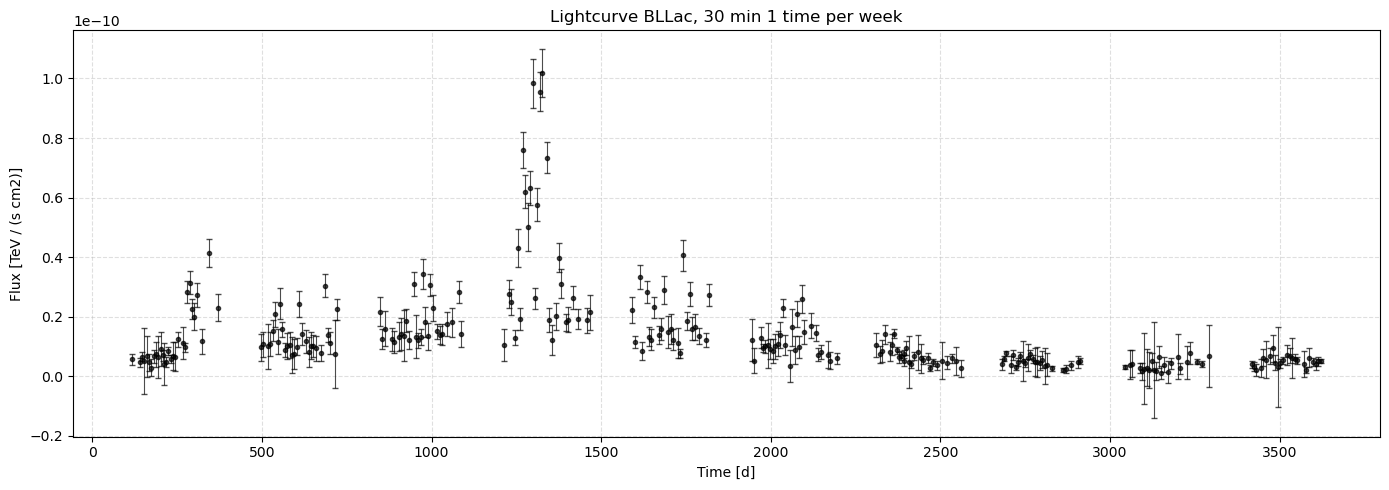

In [13]:
path = '/home/amikhno/local/30min_LC_10yr/30min_BLLac_LogParabolaExpCutoffPowerLawEBLSpectralModel.ecsv' 
table = Table.read(path)
flux = table['integrated_flux']  # * (u.ph / u.cm**2 / u.s)
flux_err = table['integrated_flux_error']  #* (u.ph / u.cm**2 / u.s)
times = (table['tstart']).to(u.day)

fig, ax = plt.subplots(figsize=(14, 5)) 
ax.errorbar(
    times.value,
    flux.value,
    yerr=flux_err.value,
    fmt='o',
    ms=3,           
    elinewidth=0.8, 
    capsize=2,      
    color='k',
    alpha=0.7
)

ax.set_xlabel(f"Time [{times.unit}]")
ax.set_ylabel(f"Flux [{flux.unit}]")
ax.grid(True, ls="--", alpha=0.4)
ax.legend(frameon=False)
plt.title(f'Lightcurve BLLac, 30 min 1 time per week')

plt.tight_layout()

In [6]:
name = "4FGL_J1800.6+7828"
index = 6
filename = f"/home/amikhno/local/src/CTAegal/LightCurves_Julian/{index}_{name}/{index}_LC_{name}_ZTF.csv"
data = Table.read(filename, format="ascii.csv")
t = data["mjd"]
phi = data["std_flux"]
ephi = data["std_flux_error"]
data

mjd,std_flux,std_flux_error
float64,float64,float64
58197.3417,0.905211928527144,0.0103959064874302
58197.3597,0.8797584933425576,0.0101371592971208
58197.39017,0.9071616208002232,0.0104157737667895
58197.41316,0.9143116811045836,0.0104886852147422
58198.3659,0.8374480357904155,0.0097096327748591
58198.39106,0.8461463166883393,0.0097972572690439
58198.4036,0.8488721165837181,0.0098247423894138
58202.28658,1.1146984252515204,0.0144146925680523
58202.30551,1.0921738842434772,0.0141764718408378


In [5]:
filename = f"/home/amikhno/Downloads/4FGL_J1800.6+7828_weekly_3_3_2026.csv"
data = Table.read(filename, format="ascii.csv")
phi_raw = data["Photon Flux [0.1-100 GeV](photons cm-2 s-1)"]
ephi_raw = data["Photon Flux Error(photons cm-2 s-1)"]
t = np.array(data["Julian Date"], dtype=float)

phi = []
ephi = []
upper_limit_mask = []

for val in phi_raw:
    val = val.strip()
    
    if val.startswith("<"):
        upper_limit_mask.append(True)
        val = val.replace("<", "").strip()
    else:
        upper_limit_mask.append(False)
        
    phi.append(float(val))

phi = np.array(phi)
upper_limit_mask = np.array(upper_limit_mask)

ephi = np.array([
    float(v) if v.strip() not in ["", "-"] else np.nan
    for v in ephi_raw
])

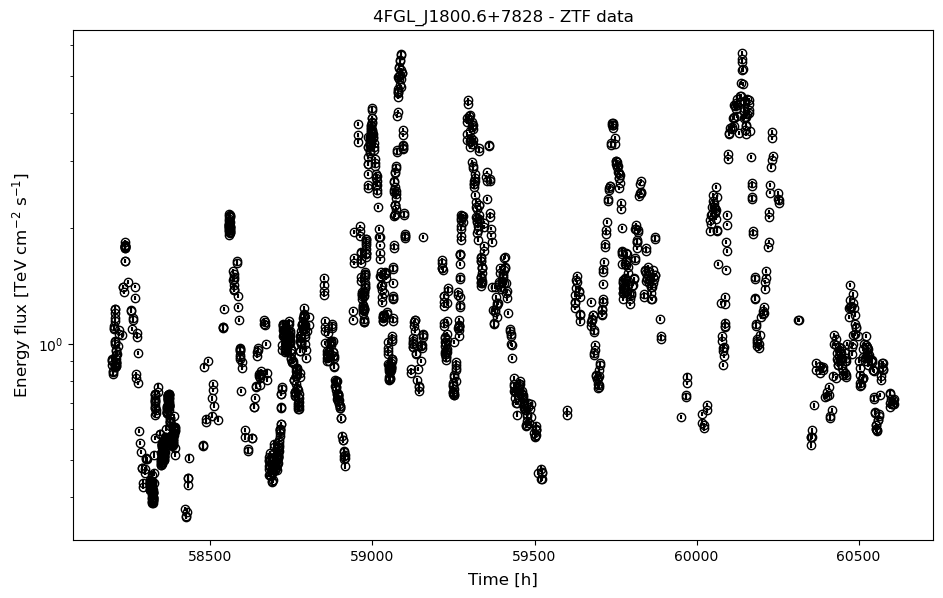

In [7]:
title = f"{name} - ZTF data"
#Plot the initial lightcurve as it is
phi_med = np.median(phi)
plot_lightcurve(title, t, phi, ephi)

In [9]:
mean, std = np.mean(phi / phi_med), np.std(phi / phi_med)
print(f"The initial parameters: mu = {mean}, dev = {std}")

params_fited_norm = fitting(phi / phi_med, ephi / phi_med, mean, std,  model="gaussian")
print(f" Gaussian fit parameters: {params_fited_norm}")

v = np.var(phi / phi_med)
sigma2 = np.log(1 + v / mean ** 2)
sigma = np.sqrt(sigma2)

mu = np.log(mean) - sigma2 / 2
params_fited_ln = fitting(phi / phi_med, ephi / phi_med, mu , sigma )
print(f" Lognormal fit parameters: {params_fited_ln}")


The initial parameters: mu = 1.3595932209595325, dev = 0.9818670017168026
Fit new parameters:
mean = 1.358963731079473
std = 0.9802899736416417
 Gaussian fit parameters: (1.358963731079473, 0.9802899736416417, np.float64(9.268321703148874e-11), np.float64(0.003563993012891956), np.float64(-2354.7042904843584), True)
Fit new parameters:
mu = 0.1016491815272208
sigma = 0.6166314078587194
 Lognormal fit parameters: (0.1016491815272208, 0.6166314078587194, np.float64(0.0038968489921300587), np.float64(0.00879221718591043), np.float64(-1744.8576983959028), True)


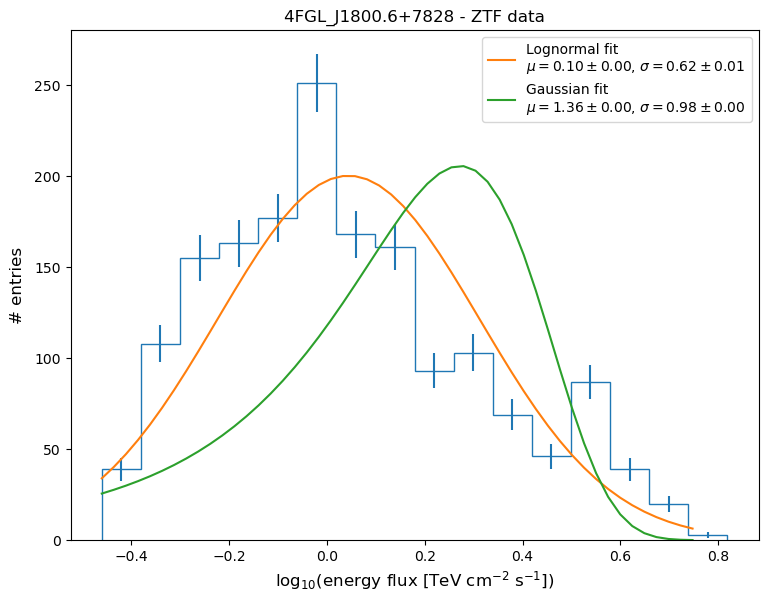

In [19]:
   #Plot the initinal data vs the fited dist

hist, bins = hist_flux(phi/ phi_med,  ephi/ phi_med, 15)


#  plot
fig, ax = plt.subplots(figsize=(8, 6), nrows=1, ncols=1)
plt.subplots_adjust(bottom=0.1, top=0.95, left=0.1, right=0.96, hspace=0.05)
ax.set_title(title)
ax.set_xlabel(r"log$_{10}$(energy flux [TeV cm$^{-2}$ s$^{-1}$])", ha="center", va='center', labelpad=12,
              fontsize=12)
ax.set_ylabel(r"# entries", ha="center", va='center', labelpad=12, fontsize=12)
# ax.set_yscale('log')
log_phi = np.log10(phi / phi_med)
ax.stairs(hist, bins)
bin_centers = 0.5 * (bins[1:] + bins[:-1])
sel = hist >= 1
ax.errorbar(bin_centers[sel], hist[sel], yerr=np.sqrt(hist[sel]), fmt='', mfc='none', color='tab:blue', ls='none')

bin_size_log10 = bins[1] - bins[0]
log10phi_plot = np.linspace(np.min(log_phi), np.max(log_phi))
phi_plot = np.power(10, log10phi_plot)
normalization_pdf = phi.size * bin_size_log10 * np.log(10)
# pdf_ln = lambda x: pdf_LogNorm(x, 0.10,0.62)
# label_lognorm = (
#     "Lognormal fit\n"
#     fr"$\mu = {0.1}\pm {0.0}$, "
#     fr"$\sigma = {0.62} \pm {0.01}$"
# )
# ax.plot(log10phi_plot, phi_plot * pdf_ln(phi_plot) * normalization_pdf, label=label_lognorm)

# pdf_norm = lambda x: pdf_Gauss(x, 1.36, 0.98)
# label_norm = ("Gaussian fit\n"
#     fr"$\mu = {1.36} \pm {0.0}$, "
#     fr"$\sigma = {0.98} \pm {0.0}$")
# ax.plot(log10phi_plot, phi_plot * pdf_norm(phi_plot) * normalization_pdf, label=label_norm)

# pdf_Alpha= lambda x: pdf_alpha_stable(x,1.94, 0.47, 1.30)
# label_alpha = (
#     "Alpha-stable fit\n"
#     fr"$\mathrm{{alpha}} = {1.94}$,"
#     fr"$\mathrm{{loc}} = {0.47}$, "
#     fr"$\mathrm{{scale}} =  {1.30}$"
# )



pdf_ln = lambda x: pdf_LogNorm(x, params_fited_ln[0], params_fited_ln[1])
label_lognorm = (
    "Lognormal fit\n"
    fr"$\mu = {params_fited_ln[0]:.2f} \pm {params_fited_ln[2]:.2f}$, "
    fr"$\sigma = {params_fited_ln[1]:.2f} \pm {params_fited_ln[3]:.2f}$"
)
ax.plot(log10phi_plot, phi_plot * pdf_ln(phi_plot) * normalization_pdf, label=label_lognorm)

pdf_norm = lambda x: pdf_Gauss(x, params_fited_norm[0], params_fited_norm[1])
label_norm = (
    "Gaussian fit\n"
    fr"$\mu = {params_fited_norm[0]:.2f} \pm {params_fited_norm[2]:.2f}$, "
    fr"$\sigma = {params_fited_norm[1]:.2f} \pm {params_fited_norm[3]:.2f}$"
)
ax.plot(log10phi_plot, phi_plot * pdf_norm(phi_plot) * normalization_pdf, label=label_norm)

# pdf_Alpha= lambda x: pdf_alpha_stable(x, params_fited_alpha[0], params_fited_alpha[1], params_fited_alpha[2])
# label_alpha = (
#     "Alpha-stable fit\n"
#     fr"$\mathrm{{alpha}} = {params_fited_alpha[0]:.2f}$,"
#     fr"$\mathrm{{loc}} = {params_fited_alpha[1]:.2f}$, "
#     fr"$\mathrm{{scale}} = {params_fited_alpha[2]:.2f}$"
# )



#ax.plot(log10phi_plot, phi_plot * pdf_Alpha(phi_plot) * normalization_pdf)

plt.legend()



Perform the simulations and the fit for Gaussian
Fit new parameters: mean = 1.0387672871405365, std = 0.2845632506332393 

### Likelihood comparison for model = gaussian ###
Generating 10 simulations...
Fitting simulations...
Fit new parameters: mean = 0.8982073020626432, std = 0.0001341272308534751 
Fit new parameters: mean = 0.8982422015929626, std = 0.1369895666059432 
Fit new parameters: mean = 0.8883839820137973, std = 0.10364381491962828 
Fit new parameters: mean = 0.8928062714837536, std = 0.1385658725482505 
Fit new parameters: mean = 0.9085727126340489, std = 0.0001253370587038023 
Fit new parameters: mean = 0.9080102511466185, std = 0.0001302669943087966 
Fit new parameters: mean = 0.8961114172294831, std = 0.1367954986717592 
Fit new parameters: mean = 0.906834700813169, std = 0.00013793649199186399 
Fit new parameters: mean = 0.9031580319588383, std = 0.0001504215670791477 
Fit new parameters: mean = 0.8943771060542346, std = 0.13571469985626003 
[-2284.08404142 -2337.73283

(array([-2284.08404142, -2337.73283864, -2326.28599296, -2345.9705618 ,
        -2286.38443273, -2288.01152134, -2328.32286408, -2284.04210021,
        -2297.62463485, -2324.03718253]),
 np.float64(1913.498764055088),
 np.float64(82.34266136829996))

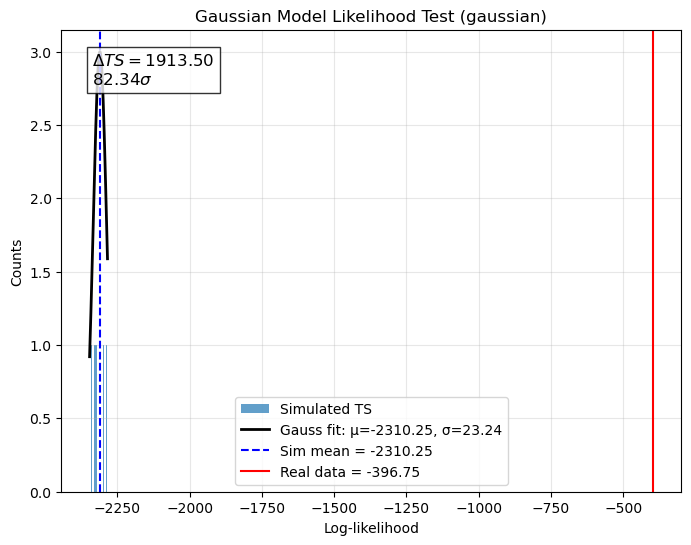

In [54]:
print("Perform the simulations and the fit for Gaussian")
params_fited_norm = fitting(phi / phi_med, ephi / phi_med, 0.1, 1.5, model="gaussian")

plot_likelihood_distribution(
    phi=phi,
    ephi=ephi,
    t=t,
    fit_params=params_fited_norm,
    model="gaussian",
    n_sim=10,
    title="Gaussian Model Likelihood Test"
)



In [55]:
print("Perform the simulations and the fit for Lognormal")

params_fited_norm = fitting(phi / phi_med, ephi / phi_med, 0.1, 1.5, model="lognorm")

plot_likelihood_distribution(
    phi=phi,
    ephi=ephi,
    t=t,
    fit_params=params_fited_norm,
    model="lognorm",
    n_sim=10,
    title="Lognorm Model Likelihood Test"
)

Perform the simulations and the fit for Lognormal
Fit new parameters: mean = 0.0018599839741402558, std = 0.26864756574146914 

### Likelihood comparison for model = lognorm ###
Generating 10 simulations...
Fitting simulations...
Fit new parameters: mean = -0.038493795152161815, std = 0.010288020423130711 


/tmp/ipykernel_16326/1727027901.py:148: RuntimeWarning: divide by zero encountered in log
  return -np.sum(np.log(likelihood))


Fit new parameters: mean = -0.03681038057649189, std = 0.010113152550731565 
Fit new parameters: mean = -0.03593215647474437, std = 0.010197766152219552 
Fit new parameters: mean = -0.05012402615580334, std = 0.010836574949244063 
Fit new parameters: mean = -0.022055185483775913, std = 0.010416965480821062 


KeyboardInterrupt: 

In [ ]:
print("Perform the simulations and the fit for Alpha-stable")

params_fited_norm = fitting(phi / phi_med, ephi / phi_med, 0.1, 1.5, model="alpha")

plot_likelihood_distribution(
    phi=phi,
    ephi=ephi,
    t=t,
    fit_params=params_fited_alpha,
    model="alpha",
    n_sim=10,
    title="Alpha model Likelihood Test"
)

